# Personalised fashion recommendations

The goal is to predict the 12 articles each customer is most likely to purchase in the following week. The primary offline metric is **MAP@12**
— the twelve are ranked, and a correct item near the top counts for more than one near the bottom.

The catalogue holds 105k articles and the history 31.8M purchases, so scoring every
customer against every article is 144 billion pairs. The system therefore uses a two-stage approach: candidate retrieval first narrows the catalogue to a few hundred plausible articles per customer, then a LightGBM LambdaRank model ranks these candidates and selects the final 12 recommendations.

The retrieval stage determines which relevant articles are available to the ranker, while the ranking stage determines their final order.

Which customer signals were worth building on was established separately, in
[`eda.ipynb`](eda.ipynb).

## 1. Configuration

First, setting the main parameters relevant to the modelling experiments, such as, the retrieval depths, feature windows, negative-sampling ratio, and temporal validation setup. They are described in detail in the sections below.

In [ ]:
import os
from pathlib import Path

import pandas as pd

from recolib.analysis import (accuracy_table, across_folds, business_table, development_metrics,
                              feature_importance_chart, fold_inputs, mean_sd,
                              per_source_report, rank_sweep, segment_chart, segment_table)
from recolib.backends import get_spark
from recolib.config import PipelineConfig
from recolib.pipeline import (build_folds, feature_summary, fold_table, train,
                              write_submission)
from recolib.pipeline.data import load_transactions
from recolib.pipeline.evaluation import score_fold

pd.set_option("display.width", 120)

cfg = PipelineConfig(
    raw_dir  = os.environ.get("HM_RAW_DIR",  str(Path.home() / "HM_dataset/hm_data")),
    out_dir  = os.environ.get("HM_WORK_DIR", str(Path.home() / "hm_data")),

    window_end  = "2020-09-22",   # the most recent week available for validation
    train_weeks = 6,
    n_folds     = 6,

    max_candidates = None,        # keep the whole union — see section 3
    seed_weeks     = 4,

    user_recent_weeks = 12,
    item_windows      = (1, 4, 12),

    train_folds            = ("fold_1", "fold_2", "fold_3", "fold_4", "fold_5"),
    negatives_per_positive = 15,

    eval_k            = 12,
    eval_sample_users = None,     # None -> score every customer
    seed              = 42,
)

EXPERIMENT_FOLDS        = list(cfg.train_folds)
EXPERIMENT_SAMPLE_USERS = None

print(cfg.summary())

In [ ]:
spark = get_spark("pipeline", driver_memory=cfg.driver_memory,
                  shuffle_partitions=cfg.shuffle_partitions,
                  console_progress=False)

spark.sparkContext.setLogLevel("ERROR")

## 2. Validation

The model is evaluated using time-based validation to reproduce the real recommendation scenario: past purchases are used to predict purchases in a future week. Six rolling weekly folds are created, with five used for development and the final fold kept untouched as the internal holdout.

Each fold uses the preceding six weeks of transactions as its main training window. Customer behaviour features can use the customer's full history available before the validation week, while item statistics and candidate seeds are calculated from the corresponding six-week window.

One deliberate asymmetry: candidate seeds and item statistics come from the fold's
six-week window, while repurchase and lifetime customer features read the customer's
entire history up to the same cutoff. Repeat buying is rare per week but spans years, and
a six-week window cannot see it.

In [3]:
folds = build_folds(load_transactions(spark, cfg), cfg)
fold_table(spark, cfg, folds)

,train start,train end,val start,train rows,val rows,train < val
fold,,,,,,
fold_0,2020-08-05,2020-09-15,2020-09-16,1614095,240311,ok
fold_1,2020-07-29,2020-09-08,2020-09-09,1678323,255241,ok
fold_2,2020-07-22,2020-09-01,2020-09-02,1713135,264657,ok
fold_3,2020-07-15,2020-08-25,2020-08-26,1719482,283181,ok
fold_4,2020-07-08,2020-08-18,2020-08-19,1749510,256644,ok
fold_5,2020-07-01,2020-08-11,2020-08-12,1821718,265211,ok
fold_submission,2020-08-12,2020-09-22,—,1565245,0,n/a


The final internal holdout is 2020-09-16 → 2020-09-22 and is not used during development.

## 3. Retrieval

The full catalogue is too large to score for every customer. Candidate generation therefore retrieves a smaller set of plausible articles from several complementary sources.

Five retrieval strategies, derived from the EDA, are used:

| source | proposes |
|---|---|
| `repurchase` | Products the customer has purchased before |
| `itemcf` | Products frequently purchased alongside the customer's recent products |
| `product_code` | Other variants of products the customer has purchased |
| `popularity` | Popular products within the customer's demographic segment |
| `graph_embedding` | Products close to the customer's historical preferences in the learned representation |

In [4]:
customers = spark.read.parquet(cfg.customers_path)

The retrieval sources use different interaction windows. Repurchase uses the customer's full purchase history, while ItemCF and product-code retrieval use purchases from the last four weeks. Graph embeddings use interactions from the fold's six-week window, while popularity provides demographic-based candidates.

Note. This makes customer activity important already at the retrieval stage. Customers without recent purchases may not receive candidates from the recent-interaction sources, leaving repurchase and demographic popularity as their main sources of candidates.

### 3.1 What each source contributes

The value of a retrieval source depends not only on how many candidates it produces, but on how many future purchases it can make available to the ranker.

The table below shows average candidate volume and recall across the five development folds.

In [5]:
sources = across_folds(per_source_report, spark, cfg, EXPERIMENT_FOLDS,
                       sample_users=EXPERIMENT_SAMPLE_USERS, customers=customers)
mean_sd(sources, ["cands/customer", "recall %"])

,cands/customer,recall %
source,,
repurchase,17.54 ± 0.09,3.06 ± 0.14
itemcf,86.71 ± 0.75,4.91 ± 0.38
product_code,17.45 ± 0.32,3.10 ± 0.31
popularity,100.00 ± 0.00,9.63 ± 1.17
graph_embedding,80.00 ± 0.00,3.19 ± 0.20
UNION,144.72 ± 0.47,14.62 ± 1.13


Popularity is the strongest individual source, reaching 9.63% recall. However, combining all five sources increases recall to 14.62%, showing that the personalised sources recover purchases that popularity alone does not retrieve.

**Decision.** Keep the five-source retrieval strategy rather than relying on popularity alone. The sources provide complementary coverage, and the union should be treated as the retrieval foundation for the ranking stage.

### 3.2 How deep each source is taken

Each retrieval source has its own candidate budget. Increasing this budget can improve recall, but also increases the number of candidates that must be processed downstream.

Recall was therefore measured at several retrieval depths.

In [6]:
depth = across_folds(rank_sweep, spark, cfg, EXPERIMENT_FOLDS,
                     sample_users=EXPERIMENT_SAMPLE_USERS, ks=(10, 30, 50, 80, 100))
mean_sd(depth)

,K<=10,K<=30,K<=50,K<=80,K<=100
source,,,,,
repurchase,1.23 ± 0.03,2.09 ± 0.07,2.59 ± 0.10,3.06 ± 0.14,3.06 ± 0.14
itemcf,1.52 ± 0.14,2.75 ± 0.23,3.55 ± 0.29,4.45 ± 0.35,4.91 ± 0.38
product_code,2.13 ± 0.21,3.10 ± 0.31,3.10 ± 0.31,3.10 ± 0.31,3.10 ± 0.31
popularity,2.88 ± 0.33,5.11 ± 0.54,6.62 ± 0.72,8.55 ± 1.00,9.63 ± 1.17
graph_embedding,0.86 ± 0.10,1.79 ± 0.15,2.43 ± 0.17,3.19 ± 0.20,3.19 ± 0.20


**Decision.** The final retrieval configuration uses K=80 for repurchase, K=100 for ItemCF, K=30 for product-code retrieval, K=100 for popularity, and K=80 for graph embeddings. These cut-offs balance retrieval coverage with candidate volume. Product-code retrieval is capped at K=30 because its recall has already saturated, while ItemCF and popularity are kept at K=100 because recall continues to improve at larger K. Repurchase and graph embeddings are capped at K=80 because additional candidates provide little extra recall.

## 4. Ranking features

Once candidates have been retrieved, the ranker needs to distinguish which articles are most relevant to each customer. The features therefore capture several different aspects of the customer–article relationship.

The 53 features are organised into four groups:

- Customer behaviour — purchase frequency, recency and historical activity.
- Item characteristics — recent sales, popularity and article attributes.
- Customer–article cross interactions — previous interaction with the article or related products.
- Retrieval provenance — which source retrieved the candidate, its source rank and how many sources retrieved it.

**Handling inactive customers.** Customer history is treated differently depending on how recently the customer purchased. For customers who purchased within the previous 12 weeks, behavioural features such as spend, purchase frequency and category mix are calculated from this recent window. For customers with no purchase during that period, the same features are calculated from their full historical record, with an activity indicator allowing the model to distinguish recent from historical behaviour. This retains historical behavioural information for customers without recent activity, rather than discarding it. However, several retrieval sources also depend on recent activity, meaning inactive customers may have both weaker behavioural signals and a smaller candidate pool.

In [7]:
features, val = fold_inputs(spark, cfg, EXPERIMENT_FOLDS[0])
feature_summary(features, cfg)

,n,columns
group,,
cross,7,"age_gap, bought_before, price_ratio, user_dept..."
customer,16,"age, club_member_status_idx, fashion_news_freq..."
item,19,"colour_group_code, department_no, garment_grou..."
retrieval,11,"graph_embedding_rank, itemcf_rank, n_sources, ..."


**Decision.** The feature set combines **customer, item, interaction and retrieval signals**, reflecting the main drivers of purchase intent identified in the EDA. Longer-history features help retain information for less active customers, while retrieval ranks and source counts allow the ranker to learn how much confidence to place in different candidate-generation strategies.

## 5. Ranking model

The ranking problem is formulated at the customer level: each customer's retrieved candidates form one ranking group, and candidates purchased during the following validation week are treated as positives. A LightGBM LambdaRank model is used to order the candidates.

In [8]:
model, train_pdf = train(spark, cfg)
print(f"{len(train_pdf):,} training rows | {int(train_pdf['label'].sum()):,} positives "
      f"| {len(model.feature_cols)} features")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.119855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7093
[LightGBM] [Info] Number of data points in the train set: 2776823, number of used features: 53


2,776,823 training rows | 173,475 positives | 53 features


The training data contains 2,776,823 candidate rows, including 173,475 positive examples across the five development folds and 53 features.

The original candidate set is highly imbalanced, with roughly 5,400 negative candidates for every positive. Negative sampling reduces this to approximately 15 negatives per positive for training while retaining the customer-level ranking structure.

**Finding.** LambdaRank is used because the objective is to **order candidates within each customer**, rather than predict purchases independently. The 15:1 negative sampling ratio keeps the ranking problem computationally manageable while retaining multiple non-purchased alternatives per customer.

### 5.1 Feature importance

The model uses 53 features spanning customer behaviour, article characteristics, customer–article interactions and retrieval provenance. Feature importance was analysed to understand which signals contributed most to the ranking decisions.

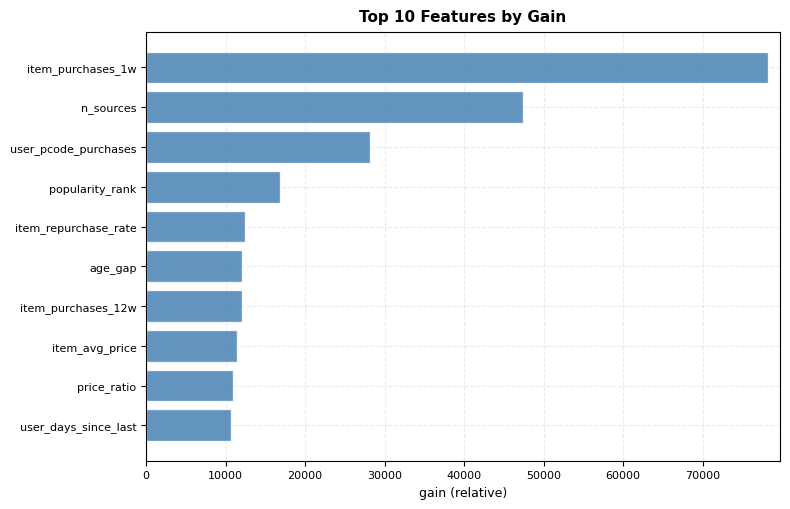

In [9]:
feature_importance_chart(model, top_n=10);

**Finding.** Recent item demand is the strongest ranking signal, with `item_purchases_1w`. The number of retrieval sources (`n_sources`) is the second strongest signal, suggesting that candidates retrieved by multiple methods are generally more relevant. Customer–article history (`user_pcode_purchases`), popularity, repurchase behaviour and customer recency also contribute strongly. Overall, the importance is spread across item, retrieval, customer and interaction signals rather than being driven by a single feature group.


## 6. Results

Model development uses rolling time-based validation, with the final week kept completely untouched as an internal holdout. This separates model selection from the final evaluation and allows us to assess whether performance is consistent across different time periods.

### 6.1 Validation metrics

The model was evaluated across four rolling validation weeks, using the same six-week history window for each week. Models for later weeks had more previous labelled data available for training, so some variation in performance is expected.

The model was compared with a bestseller baseline using MAP@12, NDCG@12, hit-rate, precision and recall. Metrics are calculated for customers who made a purchase during the respective validation week.

In [3]:
development = development_metrics(spark, cfg)
context = development.attrs["context"]
print(f"averaged over {len(context)} validation weeks, "
      f"{int(context['buyers'].min()):,}-{int(context['buyers'].max()):,} buyers each")
development

averaged over 4 validation weeks, 72,019-80,253 buyers each


,baseline,model,lift
MAP@12,0.0051 (0.0012),0.0290 (0.0031),5.8588 (1.3526)
NDCG@12,0.0106 (0.0020),0.0440 (0.0040),4.2233 (0.6345)
hit-rate@12,0.0497 (0.0081),0.1288 (0.0078),2.6265 (0.2710)
precision@12,0.0044 (0.0007),0.0129 (0.0008),2.9772 (0.2890)
recall@12,0.0184 (0.0041),0.0636 (0.0055),3.5428 (0.5020)


**Finding.** The model substantially outperformed the bestseller baseline across all metrics. MAP@12 increased from 0.0051 to 0.0290 on average, while hit-rate increased from 5.0% to 12.9%. Performance was consistently stronger across the validation period, supporting the use of the personalised ranking approach over popularity alone.

### 6.2 Final internal holdout

The complete pipeline is evaluated on the untouched week of 2020-09-16 → 2020-09-22.

The model is compared against a simple bestseller baseline that recommends the same recent bestsellers to every customer.

In [11]:
holdout = cfg.fold_names[0]          # 2020-09-16 -> 09-22, never trained on
scored  = score_fold(spark, cfg, model, holdout)
print(scored)

fold_0: 1,371,980 customers scored, 68,984 bought that week


This evaluation covers all 1.37M customers, of whom 68,984 made a purchase during the validation week.

In [12]:
accuracy = accuracy_table(scored, cfg)
print(f"MAP@12 across the whole customer base, including the "
      f"{accuracy.attrs['customers'] - accuracy.attrs['buyers']:,} who bought nothing "
      f"that week: {accuracy.attrs['kaggle_map']:.5f}")
accuracy.round(4)

MAP@12 across the whole customer base, including the 1,302,996 who bought nothing that week: 0.00166


,baseline,model,lift
MAP@12,0.0055,0.0330,6.0151
NDCG@12,0.0111,0.0489,4.3852
hit-rate@12,0.0497,0.1369,2.7544
precision@12,0.0043,0.0140,3.2481
recall@12,0.0193,0.0699,3.6199


**Finding.** The model substantially outperforms the bestseller baseline across every ranking metric.

Among customers who purchased during the holdout week, 13.69% had at least one of their
purchased articles in the model's top 12 recommendations, compared with 4.97% for the
bestseller baseline.

The holdout is consistently stronger than the validation period across all metrics. This consistency suggests the difference is unlikely to be metric-specific noise. The most plausible explanation is that the final model and holdout setup provide slightly more favourable conditions than the development folds, although this is not isolated experimentally. Importantly, the baseline performs almost identically in both periods, indicating that the stronger holdout result is driven by the model rather than an unusually easy week.

### 6.3 Commercial diagnostics

Ranking quality and commercial value are not the same thing. Every figure is shown
against what the business would do with no model — the same recent bestsellers to
everyone.

- **revenue captured** weights each correct prediction by the article's price, separating
  a model that finds many cheap purchases from one that finds the purchases carrying the
  money. **purchases captured** is the same thing unweighted.
- **price of recommended / purchased** below 1 means the model recommends items that are, on average, cheaper than the items customers actually purchase.
- **new arrivals** is how much current-season stock the recommendations expose; the EDA
  established what share of demand new arrivals actually account for.
- **replenishment share** splits correct predictions into items the customer had bought
  before and items they had not — repeat business against discovery.
- **catalogue coverage** is the share of the catalogue that ever reaches anyone's twelve
  slots.

In [13]:
business_table(spark, cfg, scored).round(2)

,model,baseline
revenue captured %,5.91,1.81
purchases captured %,5.41,1.67
price of recommended / purchased,0.99,1.08
new arrivals in recommendations %,15.14,8.33
replenishment share of hits %,53.28,8.37
catalogue coverage %,22.09,0.01


**Finding.** The model captures **5.91% of revenue and 5.41% of purchases**, compared with 1.81% and 1.67% for the baseline. It also exposes more new arrivals (**15.14% vs 8.33%**) and a much broader share of the catalogue (**22.09% vs 0.01%**). With **53.28% of hits being replenishment items**, the model appears particularly effective at recovering repeat demand, although offline results cannot establish incremental commercial impact.

**Note.** These are relative figures. H&M's `price` field is scaled rather than currency, there is
no margin data so revenue is not profit, and returns are not in the dataset. Most
importantly this is an offline measurement with no counterfactual: it describes what the
model would have surfaced from that week's candidates, not how customers would have
responded had they seen it. Only a live test answers that.

### 6.4 Customer segments

An aggregate hides the interesting part. Split by how recently each customer last bought,
on the same boundaries the EDA used.

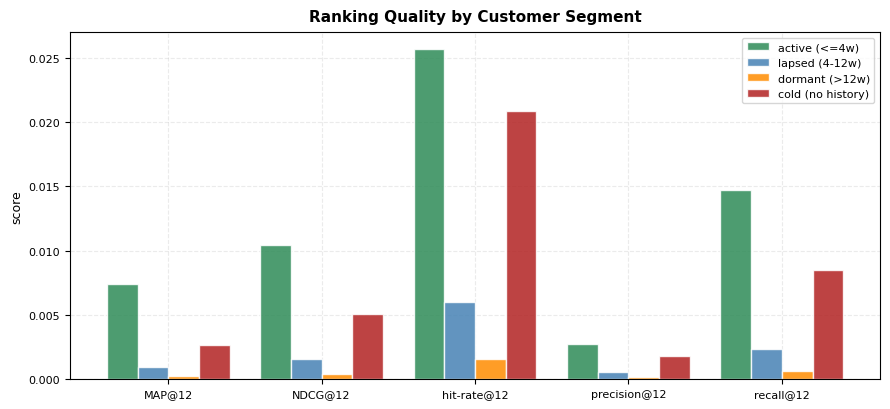

In [14]:
segments = segment_table(spark, cfg, scored)
segment_chart(segments);

**Finding.** Recommendation quality is strongly dependent on customer activity. Active customers (≤4 weeks since last purchase) perform best across all ranking metrics, while performance declines substantially for lapsed and especially dormant customers.

Customers with no purchase history behave differently: hit-rate and recall remain relatively high, consistent with the contribution of popularity-based candidates, but low MAP@12 and NDCG@12 indicate limited ability to rank recommendations precisely.

The weaker performance of inactive customers has two components. Their behavioural features contain less information about current preferences, while several retrieval sources also depend on recent interactions. Consequently, inactive customers may enter the ranking stage with both weaker personal signals and a smaller candidate pool.

**Decision.** Treat inactive customers as a retrieval and ranking problem, with retrieval coverage being the clearest opportunity for improvement.

## 7. The model that ships

The data comes from **H&M's Personalized Fashion Recommendations** competition on Kaggle.
It ends on 2020-09-22, and the week that follows — **2020-09-23 → 09-29** — is withheld:
its purchases are held by the organisers and were never available to tune against, which
is what makes it a real test rather than another held-out sample.

After internal evaluation, the final model is retrained using all six available weeks of historical data, including the period previously reserved for development validation.

In [15]:
final_cfg = cfg.with_(
    train_folds     = tuple(cfg.fold_names),        # all six weeks, holdout included
    submission_path = "submission_6fold.csv",
)
final_model, final_frame = train(spark, final_cfg)
print(f"{len(final_frame):,} training rows | {int(final_frame['label'].sum()):,} positives "
      f"| trained on {len(final_cfg.train_folds)} weeks")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.107601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7096
[LightGBM] [Info] Number of data points in the train set: 3358651, number of used features: 53


3,358,651 training rows | 209,905 positives | trained on 6 weeks


The final training set contains 3,358,651 candidate rows, including 209,905 positives, covering all 1,371,980 customers.

The model is then used to generate the competition submission for the following week.

In [16]:
submission = write_submission(spark, final_cfg, final_model)
print(f"{len(submission):,} rows -> {final_cfg.submission_path}")
submission.head()

1,371,980 rows -> submission_6fold.csv


,customer_id,prediction
0,000346516dd355b40badca0c0f5f37a318ddae31f0e0f7...,0866731001 0762846031 0372860001 0865799006 08...
1,0005baed366933727a0ee8407c56e5f065fd5b09c71478...,0915529003 0923758001 0751471001 0918292001 08...
2,001054cdd36af42fb6a33bafbf68564f61abaff0e8ddb7...,0448509014 0708138021 0768912001 0924243001 04...
3,00211fdd9b0c202c157eba0bcc7e05c175211ddbfa2253...,0866731001 0448509014 0924243001 0751471001 09...
4,0022058e10f379f15908ad251d76aa436098140cdb5ae1...,0751471001 0915529003 0852584001 0751471043 07...


**Finding.** The submitted model achieved:

- Public leaderboard MAP@12: **0.02906**
- Private leaderboard MAP@12: **0.02905**
- Bestseller baseline: 0.00541

## 8. Conclusions

### 8.1 What worked

The two-stage system substantially outperformed the bestseller baseline. On the internal holdout, MAP@12 improved from 0.0055 to 0.0330, while the final Kaggle submission achieved 0.02906 on the public leaderboard and 0.02905 privately.

The improvement is also consistent across NDCG, hit-rate, precision and recall rather than being driven by a single metric.

### 8.2 Main limitation

The largest limitation is candidate retrieval. The five-source union reaches 14.62 ± 1.13% recall, meaning most future purchases are still not available to the ranker.

This makes retrieval coverage the clearest bottleneck in the current architecture.

### 8.3 What is fragile

Popularity is the strongest individual retrieval source, but also shows the largest variation across development weeks (±1.17 percentage points). The personalised sources are individually weaker, but their recall is more stable.

This suggests that the system benefits from combining sources rather than depending on popularity alone.

### 8.4 Weakest area

Repeat behaviour is an important component of the model's successful predictions: 53.28% of correct recommendation hits are replenishment items.

Performance also falls sharply with customer inactivity, from 0.0073 MAP@12 for active customers to 0.0002 for dormant customers.

This is not only a ranking problem. Dormant customers have weaker recent behavioural signals and, because several retrieval sources depend on recent interactions, they also receive candidates from a substantially smaller set of sources. Their performance is therefore constrained by both candidate coverage and signal quality.

These are the clearest areas where additional modelling could add value.

### 8.5 What cannot be concluded

The evaluation is based on one offline holdout week and observed purchases. It therefore cannot establish that recommendations caused additional purchases or revenue.

The commercial metrics should be interpreted as evidence of offline purchase matching and catalogue exposure, not incremental business impact.

### 8.6 Next priority

The next improvement should focus on candidate retrieval rather than extensive ranker tuning.

In particular:

- Increase ItemCF and popularity retrieval depth, where recall was still increasing at K=100.
- Explore additional retrieval sources that can recover purchases outside the current candidate union.
- Improve retrieval for lapsed and dormant customers.
- Only then invest heavily in further ranker optimisation, once more relevant items are available to rank.

The central lesson from the pipeline is therefore:

The ranker is already able to improve substantially over popularity, but its potential is constrained by what retrieval makes available in the first place.

In [17]:
spark.stop()